## **PERTANYAAN BISNIS**

1. Apakah kualitas dataset gambar sampah berdasarkan konsistensi ukuran gambar, format file, dan jumlah data duplikat sudah memenuhi kebutuhan proses training model pada tahap persiapan data?
2. ⁠Bagaimana distribusi warna dan tingkat pencahayaan pada setiap kategori sampah memengaruhi kebutuhan preprocessing gambar dalam pengembangan model EcoSort AI?
3. Bagaimana kemampuan fitur hasil ekstraksi gambar dalam membedakan kategori sampah berdasarkan persebaran fitur PCA pada tahap pengembangan model EcoSort AI?

## **IMPORT LIBRARY**

In [44]:
# Mengimport library yang dibutuhkan
import os
import cv2
import shutil
import stat
import random
import hashlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

## **ASSESING DATA**

In [ ]:
dataset_path = "Dataset Capstone"
class_counts = {}

print("=== JUMLAH DATA PER KELAS ===\n")

for root, dirs, files in os.walk(dataset_path):
    if len(files) > 0:
        class_name = os.path.basename(root)
        class_counts[class_name] = len(files)
        print(f"{class_name}: {len(files)} gambar")

print("\nTotal gambar:", sum(class_counts.values()))

=== JUMLAH DATA PER KELAS ===

B3: 200 gambar
Glass: 200 gambar
Metal: 200 gambar
Organic: 200 gambar
Paper: 200 gambar
Plastic: 200 gambar

Total gambar: 1200


### **MENGECEK FILE CORRUPT ATAU RUSAK**

In [46]:
corrupt_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            img.verify()
        except:
            corrupt_files.append(path)

print("=== FILE CORRUPT ===")
print("Jumlah:", len(corrupt_files))

for f in corrupt_files[:10]:
    print(f)

=== FILE CORRUPT ===
Jumlah: 0


In [47]:
sizes = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            sizes.append(img.size)
        except:
            pass

print("=== SAMPLE UKURAN GAMBAR ===")
print(random.sample(sizes, 5))

small_images = [s for s in sizes if s[0] < 100 or s[1] < 100]
print("\nJumlah gambar kecil (<100px):", len(small_images))

=== SAMPLE UKURAN GAMBAR ===
[(184, 274), (150, 150), (150, 150), (512, 384), (512, 384)]

Jumlah gambar kecil (<100px): 0


### **PENGECEKAN DATA DUPLIKAT**

=== DUPLIKAT ===
Jumlah: 3


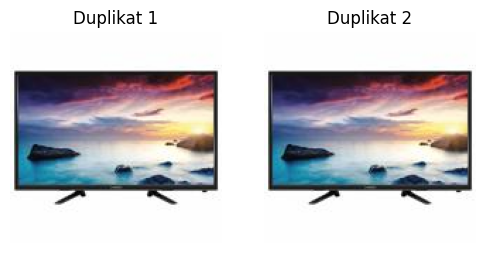

Path 1: Dataset Capstone\B3\Television_245.jpg
Path 2: Dataset Capstone\B3\Television_238.jpg
--------------------------------------------------


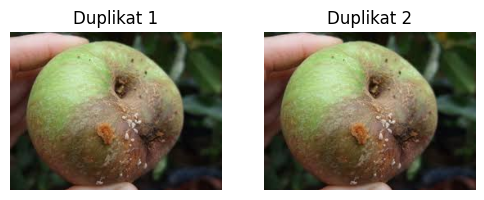

Path 1: Dataset Capstone\Organic\O_10174.jpg
Path 2: Dataset Capstone\Organic\organic_000197_photo.jpg
--------------------------------------------------


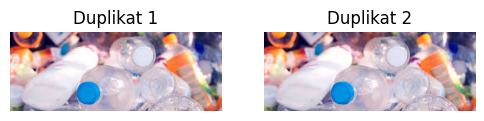

Path 1: Dataset Capstone\Plastic\R_1024.jpg
Path 2: Dataset Capstone\Plastic\R_1024 (1).jpg
--------------------------------------------------


In [48]:
hashes = {}
duplicates = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            with open(path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in hashes:
                duplicates.append((path, hashes[file_hash]))
            else:
                hashes[file_hash] = path
        except:
            pass

print("=== DUPLIKAT ===")
print("Jumlah:", len(duplicates))

for dup in duplicates[:5]:
    img1_path, img2_path = dup

    img1 = Image.open(img1_path)
    img2 = Image.open(img2_path)

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Duplikat 1")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("Duplikat 2")
    plt.axis('off')

    plt.show()

    print("Path 1:", img1_path)
    print("Path 2:", img2_path)
    print("-"*50)

### **MENGECEK FORMAT FILE**

In [49]:
formats = {}

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        ext = file.split('.')[-1].lower()
        formats[ext] = formats.get(ext, 0) + 1

print("=== FORMAT FILE ===")
for k, v in formats.items():
    print(f"{k}: {v}")

=== FORMAT FILE ===
jpeg: 54
jpg: 1146


### **MENGCEK KECERAHAN GAMBAR**

In [50]:
brightness = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path).convert('L')
            brightness.append(np.mean(img))
        except:
            pass

print("=== BRIGHTNESS ===")
print("Min:", min(brightness))
print("Max:", max(brightness))
print("Mean:", sum(brightness)/len(brightness))

=== BRIGHTNESS ===
Min: 25.227795006361323
Max: 247.02596291580454
Mean: 157.3849474311216


## **PREPROCESSING**

In [51]:
# Menghapus duplikat
dataset_path = "Dataset Capstone"
clean_path = "Dataset_Cleaned"

def remove_readonly(func, path, _):
    os.chmod(path, stat.S_IWRITE)
    func(path)

# hapus folder lama 
if os.path.exists(clean_path):
    shutil.rmtree(clean_path, onerror=remove_readonly)

# copy dataset
shutil.copytree(dataset_path, clean_path)

hashes = {}
duplicates = []
total_clean = 0

# proses di dataset hasil copy
for root, dirs, files in os.walk(clean_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            with open(path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in hashes:
                duplicates.append(path)
            else:
                hashes[file_hash] = path
        except:
            pass
    total_clean += len(files)

# hapus duplikat di dataset_cleaned
for file in duplicates:
    os.remove(file)

total_clean = 0
for root, dirs, files in os.walk(clean_path):
    total_clean += len(files)

print("Duplikat dihapus di dataset_cleaned:", len(duplicates))
print("Total data setelah hapus duplikat:", total_clean)

Duplikat dihapus di dataset_cleaned: 3
Total data setelah hapus duplikat: 1197


In [52]:
# Mengkonversi format file 
formats_before = {}

for root, dirs, files in os.walk(clean_path):
    for file in files:
        ext = file.split('.')[-1].lower()
        formats_before[ext] = formats_before.get(ext, 0) + 1

print("=== FORMAT SEBELUM KONVERSI ===")
for k, v in formats_before.items():
    print(f"{k}: {v}")

# Konversi JPEG -> JPG 
converted = 0

for root, dirs, files in os.walk(clean_path):
    for file in files:
        if file.lower().endswith(".jpeg"):
            old_path = os.path.join(root, file)
            new_path = os.path.join(root, file.replace(".jpeg", ".jpg"))

            try:
                img = Image.open(old_path)
                img = img.convert("RGB")
                img.save(new_path, "JPEG")

                os.remove(old_path)
                converted += 1

            except Exception as e:
                print(f"[ERROR] {old_path} | {e}")

#  Mengecek format hasil konversi
formats_after = {}

for root, dirs, files in os.walk(clean_path):
    for file in files:
        ext = file.split('.')[-1].lower()
        formats_after[ext] = formats_after.get(ext, 0) + 1

print("\n=== FORMAT SESUDAH KONVERSI ===")
for k, v in formats_after.items():
    print(f"{k}: {v}")

print("\nJumlah file berhasil dikonversi (JPEG => JPG):", converted)

=== FORMAT SEBELUM KONVERSI ===
jpeg: 54
jpg: 1143

=== FORMAT SESUDAH KONVERSI ===
jpg: 1197

Jumlah file berhasil dikonversi (JPEG => JPG): 54


In [53]:
# Mengganti nama atau rename supaya lebih rapi
counter_dict = {}
all_renames = []

for root, dirs, files in os.walk(clean_path):
    class_name = os.path.basename(root)

    if class_name not in counter_dict:
        counter_dict[class_name] = 1

    for file in files:
        ext = file.split('.')[-1]
        new_name = f"{class_name}_{counter_dict[class_name]:03d}.{ext}"

        old_path = os.path.join(root, file)
        new_path = os.path.join(root, new_name)

        os.rename(old_path, new_path)

        # simpan semua hasil rename
        all_renames.append((file, new_name, class_name))

        counter_dict[class_name] += 1

examples = random.sample(all_renames, min(5, len(all_renames)))

print("Rename selesai! Berikut contoh hasil rename:")
for old, new, cls in examples:
    print(f"{old} -> {new}")

Rename selesai! Berikut contoh hasil rename:
O_10020.jpg -> Organic_109.jpg
glass150.jpg -> Glass_029.jpg
paper276.jpg -> Paper_096.jpg
plastic313.jpg -> Plastic_129.jpg
O_10047.jpg -> Organic_123.jpg


In [54]:
# Mengubah ukuran gambar atau resize image 
IMG_SIZE = 300
sample_shown = False  

for root, dirs, files in os.walk(clean_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path).convert("RGB")

            # ambil ukuran sebelum
            before_size = img.size

            # resize
            img = img.resize((IMG_SIZE, IMG_SIZE))
            after_size = img.size

            img.save(path)

            # Menampilkan contoh hasil resize
            if not sample_shown:
                print("Resize selesai! Berikut contoh hasil resize:")
                print(f" Nama File     : {file}")
                print(f"Sebelum resize : {before_size}")
                print(f"Sesudah resize : {after_size}")
                sample_shown = True

        except Exception as e:
            print("Error:", path, e)

Resize selesai! Berikut contoh hasil resize:
 Nama File     : B3_001.jpg
Sebelum resize : (150, 150)
Sesudah resize : (300, 300)


In [55]:
# Melakukan denoising dan normalisasi
IMG_SIZE = 300

def preprocess_image(image):
    results = {}

    # 1. Original (convert BGR → RGB untuk display)
    results['Original'] = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 2. Resize
    resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    results['Resized'] = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    # 3. Denoising
    denoised = cv2.GaussianBlur(resized, (3, 3), 0)
    results['Denoised'] = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

    # 4. Normalisasi (untuk model, tidak ditampilkan langsung)
    normalized = denoised / 255.0
    results['Normalized'] = normalized

    return results

def display_preprocessing_results(processed, title_prefix=""):
    stages = list(processed.keys())
    num_stages = len(stages)

    plt.figure(figsize=(18, 4))

    for i, stage in enumerate(stages):
        plt.subplot(1, num_stages, i+1)
        img = processed[stage]

        if isinstance(img, np.ndarray) and img.max() <= 1.0:
            # normalized image
            plt.imshow(img)
        else:
            plt.imshow(img)
        
        plt.title(f"{stage}", fontsize=14, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


Kategori: B3


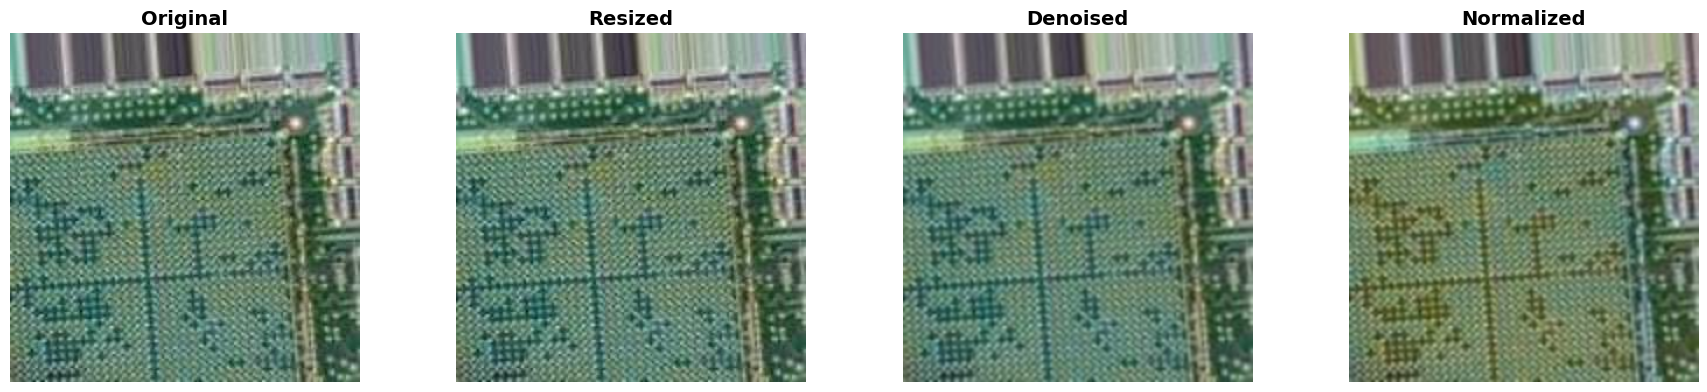


Kategori: Glass


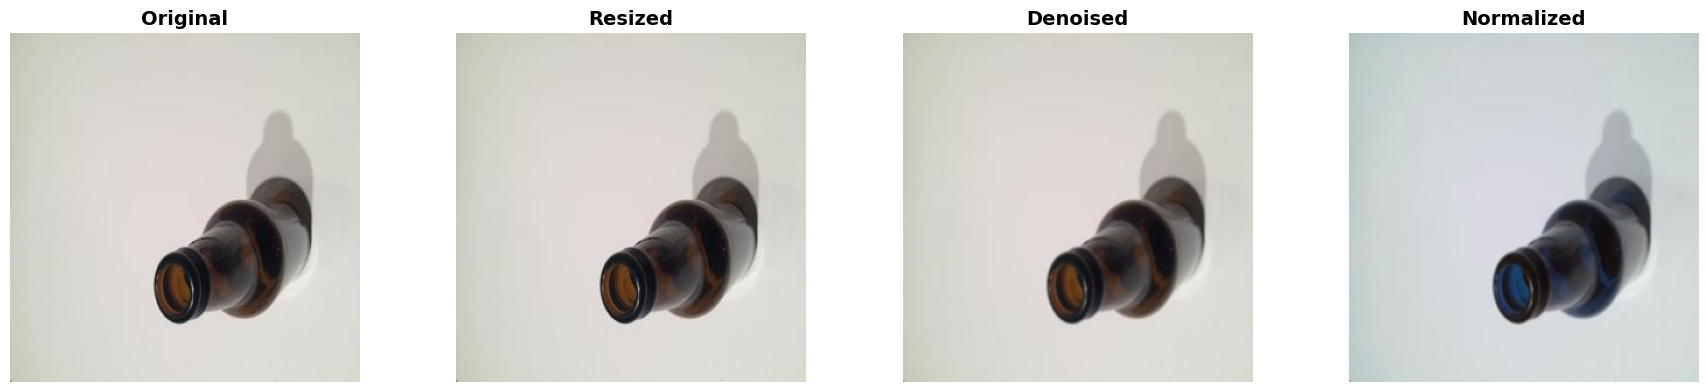


Kategori: Metal


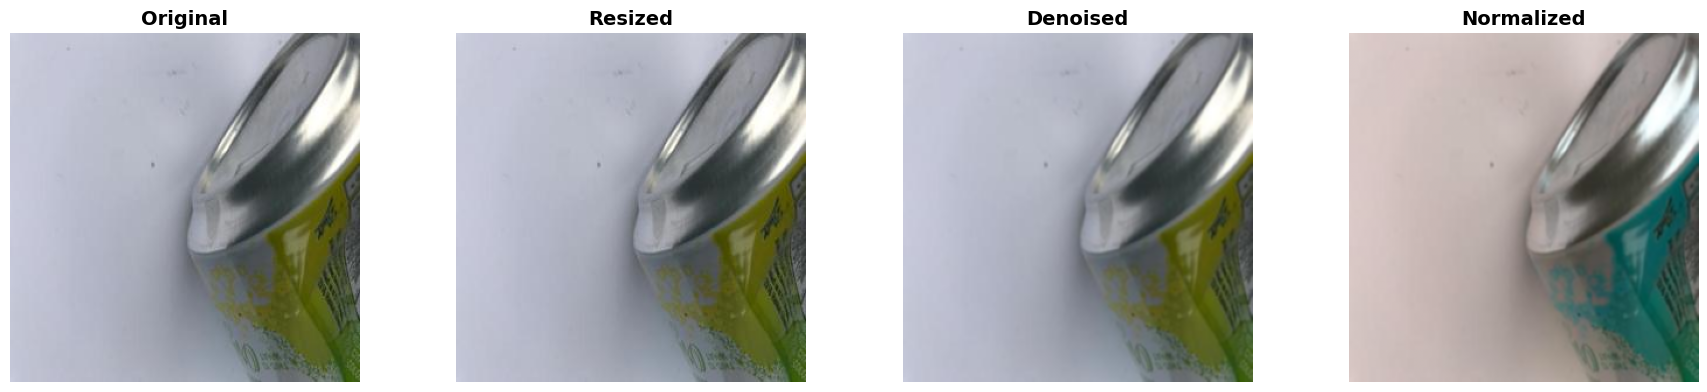


Kategori: Organic


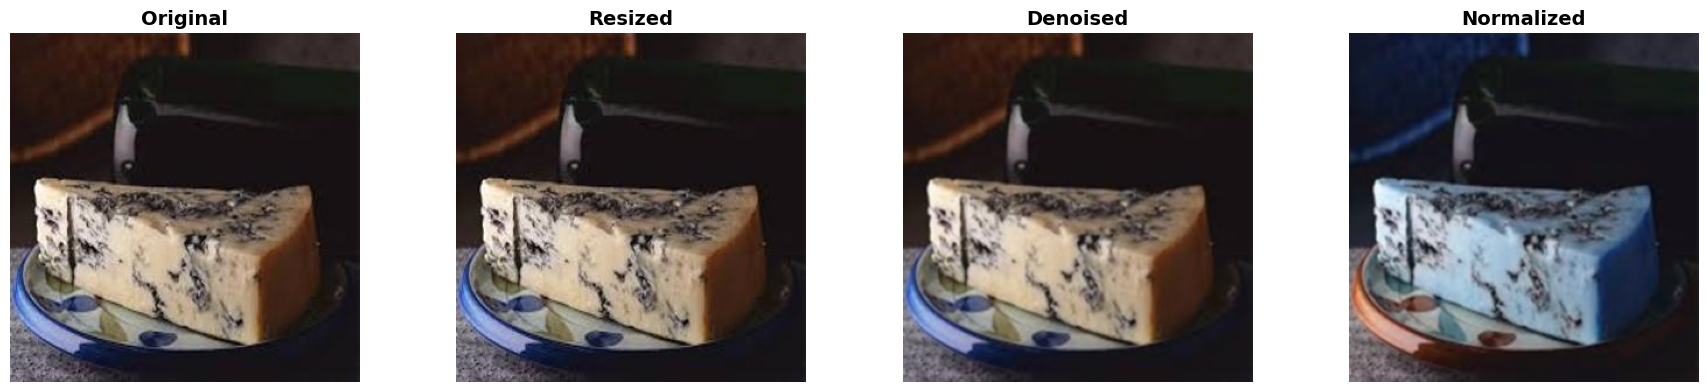


Kategori: Paper


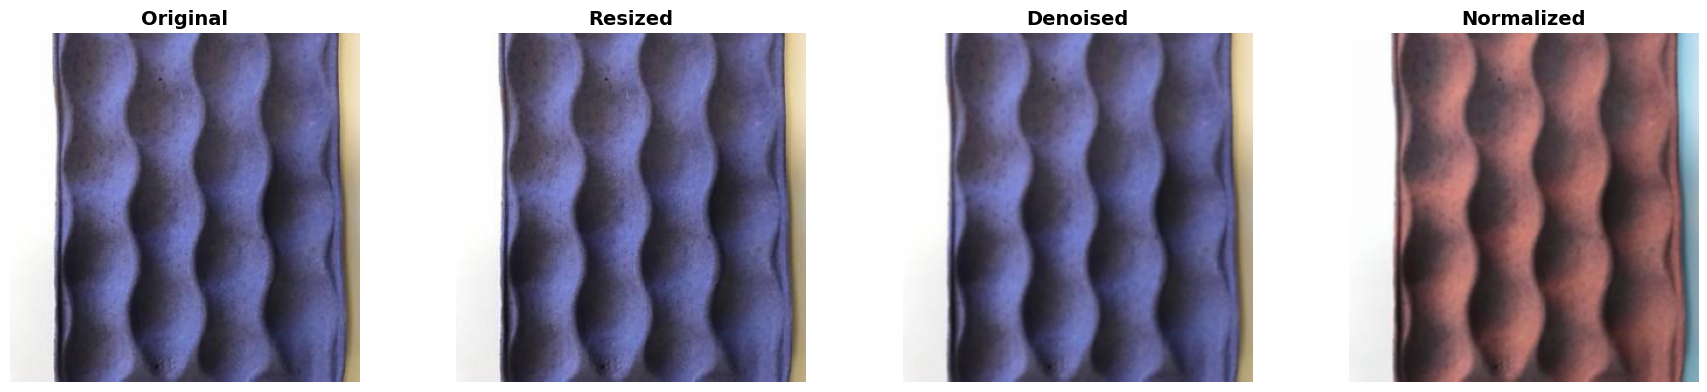


Kategori: Plastic


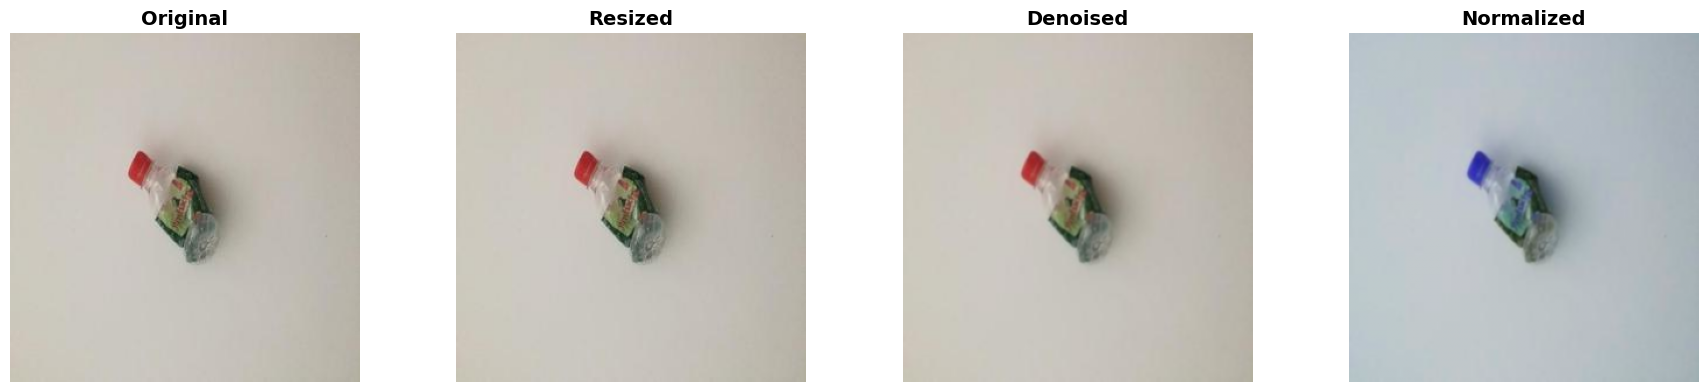

In [56]:
# Menampilkan hasil resize, denoised dan normalisasi
contoh_per_kategori = {}

for root, dirs, files in os.walk(clean_path):
    label = os.path.basename(root)

    for file in files:
        path = os.path.join(root, file)
        image = cv2.imread(path)

        if image is None:
            continue

        processed = preprocess_image(image)

        # ambil hanya 1 contoh per kelas
        if label not in contoh_per_kategori:
            contoh_per_kategori[label] = processed

for label, processed in contoh_per_kategori.items():
    print(f"\nKategori: {label}")
    display_preprocessing_results(processed)

In [57]:
IMG_SIZE = 300
total_processed = 0

for root, dirs, files in os.walk(clean_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            # baca gambar
            image = cv2.imread(path)

            if image is None:
                continue

            # Resize
            resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            # Denoising
            denoised = cv2.GaussianBlur(resized, (3,3), 0)

            # simpan overwrite ke Dataset_Cleaned
            cv2.imwrite(path, denoised)

            total_processed += 1

        except Exception as e:
            print(f"Error {path}: {e}")

print("Preprocessing selesai disimpan!")
print("Total gambar diproses:", total_processed)
print("Dataset_Cleaned sekarang berisi:")
print("Tidak ada duplikat")
print("Format sudah konsisten")
print("Nama file rapi")
print("Ukuran 224x224")
print("Sudah denoising")
print("Siap untuk training")

Preprocessing selesai disimpan!
Total gambar diproses: 1197
Dataset_Cleaned sekarang berisi:
Tidak ada duplikat
Format sudah konsisten
Nama file rapi
Ukuran 224x224
Sudah denoising
Siap untuk training


## **EXPLORATORY DATA ANALYSIS (EDA)**

### **DISTRIBUSI JUMLAH DATA PERKELAS**

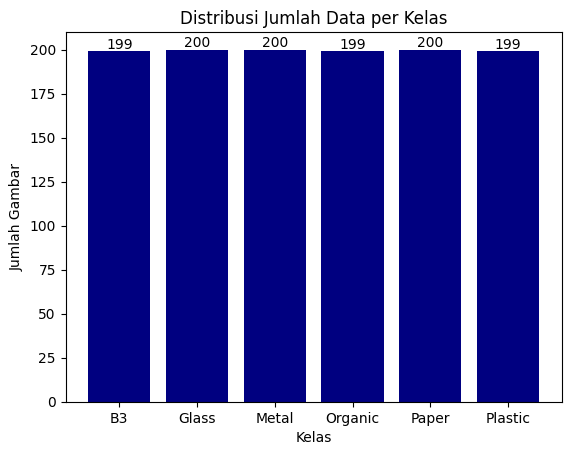

In [58]:
class_counts = {}

for folder in os.listdir(clean_path):
    path = os.path.join(clean_path, folder)
    if os.path.isdir(path):
        class_counts[folder] = len(os.listdir(path))

kelas = list(class_counts.keys())
jumlah = list(class_counts.values())

max_value = max(jumlah)

colors = ["navy" if v == max_value else "navy" for v in jumlah]

# plot
plt.figure()
bars = plt.bar(kelas, jumlah, color=colors)

plt.title("Distribusi Jumlah Data per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=0)
plt.show()

### **DISTRIBUSI UKURAN DATA**

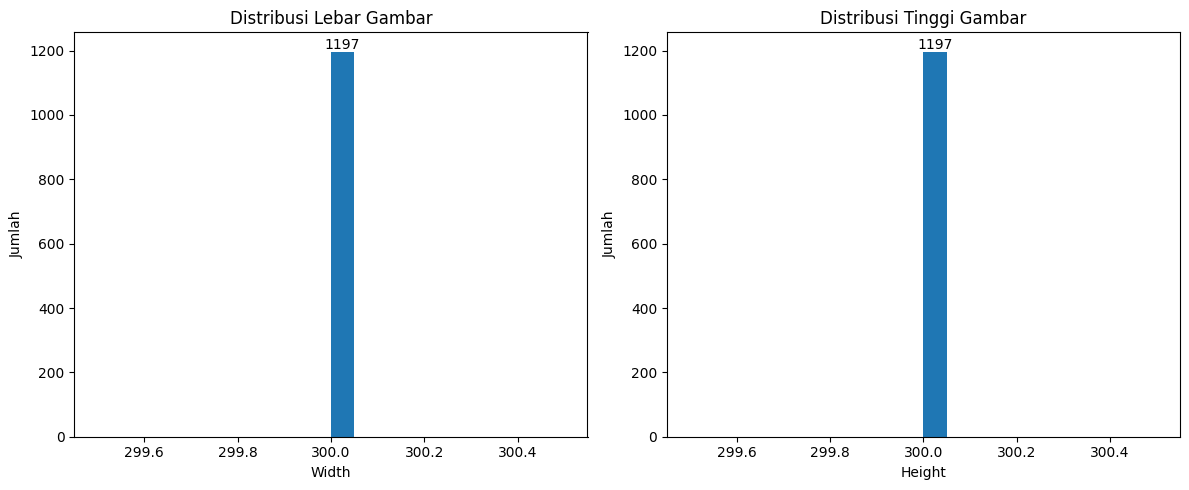

In [59]:
sizes = []

for root, dirs, files in os.walk(clean_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            sizes.append(img.size)
        except:
            pass

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
counts_w, bins_w, patches_w = plt.hist(widths, bins=20)
plt.title("Distribusi Lebar Gambar")
plt.xlabel("Width")
plt.ylabel("Jumlah")

for count, patch in zip(counts_w, patches_w):
    if count > 0:
        x = patch.get_x() + patch.get_width()/2
        y = patch.get_height()
        plt.text(x, y, str(int(count)), ha='center', va='bottom')


# 🔹 Histogram Height (kanan)
plt.subplot(1,2,2)
counts_h, bins_h, patches_h = plt.hist(heights, bins=20)
plt.title("Distribusi Tinggi Gambar")
plt.xlabel("Height")
plt.ylabel("Jumlah")

for count, patch in zip(counts_h, patches_h):
    if count > 0:
        x = patch.get_x() + patch.get_width()/2
        y = patch.get_height()
        plt.text(x, y, str(int(count)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### **DISTRIBUSI KECERAHAN**

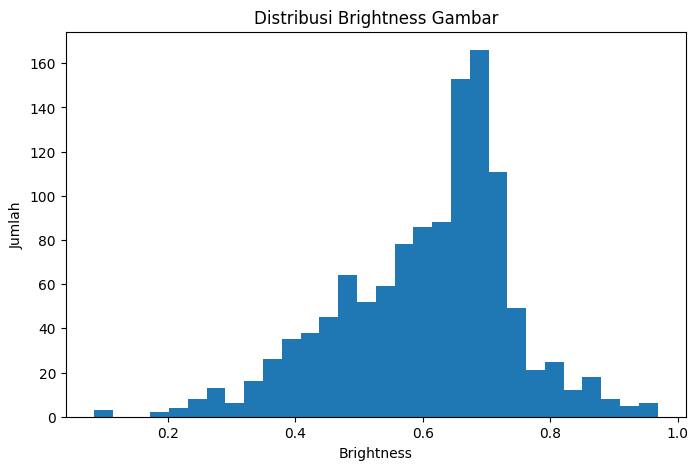

In [60]:
brightness = []

for root, dirs, files in os.walk(clean_path):

    for file in files:

        path = os.path.join(root, file)

        image = cv2.imread(path)

        if image is None:
            continue

        processed = preprocess_image(image)

        # hasil normalized
        img = processed['Normalized'].astype(np.float32)

        # grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # hitung brightness
        brightness.append(np.mean(gray))

# visualisasi
plt.figure(figsize=(8,5))

plt.hist(brightness, bins=30)

plt.title("Distribusi Brightness Gambar")
plt.xlabel("Brightness")
plt.ylabel("Jumlah")

plt.show()

### **SAMPLE GAMBAR**

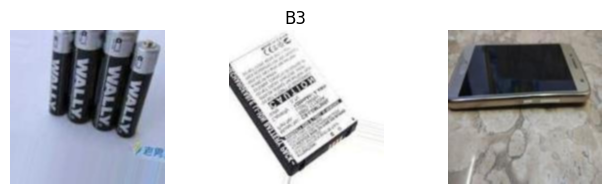

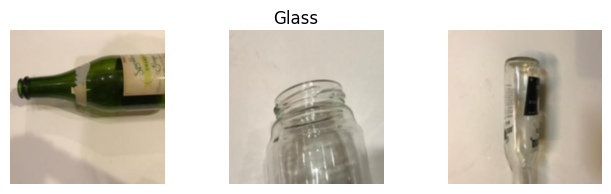

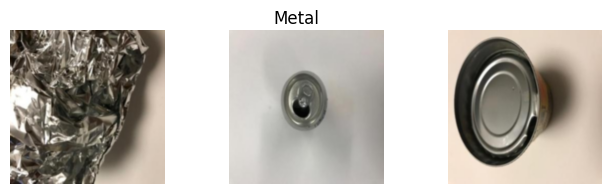

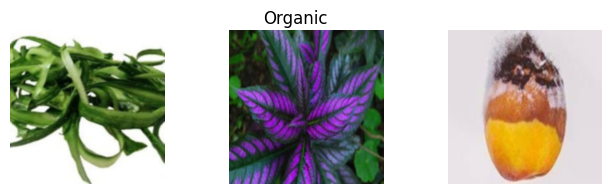

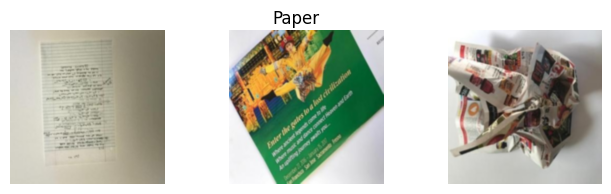

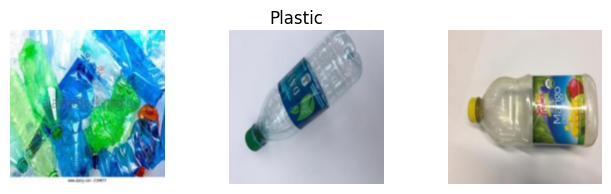

In [61]:
def show_samples(folder, n=3):
    files = os.listdir(folder)
    samples = random.sample(files, min(n, len(files)))

    plt.figure(figsize=(8,2))

    for i, f in enumerate(samples):

        path = os.path.join(folder, f)

        image = cv2.imread(path)

        if image is None:
            continue

        # preprocess
        processed = preprocess_image(image)

        # ambil hasil denoised / normalized / resized
        img = processed['Denoised']

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(os.path.basename(folder))
    plt.show()

for folder in os.listdir(clean_path):
    path = os.path.join(clean_path, folder)

    if os.path.isdir(path):
        show_samples(path)

### **SEBELUM VS SESUDAH RESIZE**

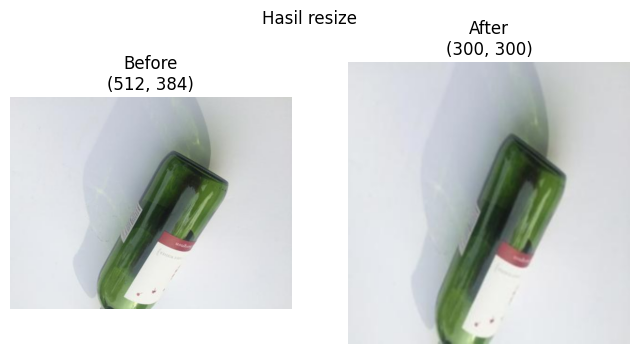

In [62]:
kelas = "Glass"

raw_folder = os.path.join(dataset_path, kelas)
raw_files = sorted(os.listdir(raw_folder))
raw_sample = os.path.join(raw_folder, raw_files[2])

clean_folder = os.path.join(clean_path, kelas)
clean_files = sorted(os.listdir(clean_folder))
clean_sample = os.path.join(clean_folder, clean_files[2])

before = Image.open(raw_sample).convert("RGB")
after = Image.open(clean_sample).convert("RGB")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(before)
plt.title(f"Before\n{before.size}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(after)
plt.title(f"After\n{after.size}")
plt.axis("off")

plt.suptitle("Hasil resize")
plt.show()

## **EXTRAKSI FITUR**

In [63]:
IMG_SIZE = 300
BATCH_SIZE = 32

all_gen = ImageDataGenerator()

all_data = all_gen.flow_from_directory(
    clean_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# model ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

# fungsi ekstraksi fitur
def extract_features(generator):

    features = []
    labels = []

    generator.reset()

    total_batch = len(generator)

    for i in range(total_batch):

        x_batch, y_batch = next(generator)

        # preprocessing khusus ResNet50
        x_batch = preprocess_input(x_batch)

        # ekstraksi fitur
        feat = base_model.predict(x_batch, verbose=0)

        features.append(feat)
        labels.append(y_batch)

    return np.vstack(features), np.vstack(labels)

# ekstraksi fitur seluruh data
X_features, y_labels = extract_features(all_data)

print("Shape fitur:", X_features.shape)
print("Shape label:", y_labels.shape)

Found 1197 images belonging to 6 classes.
Shape fitur: (1197, 2048)
Shape label: (1197, 6)


In [64]:
X_all_feat = X_features
y_all_feat = y_labels

filenames = all_data.filenames
filenames = [os.path.basename(f) for f in filenames]

# label numerik
labels = np.argmax(y_all_feat, axis=1)

# mapping index -> nama kelas
class_indices = all_data.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

# nama label
label_names = [idx_to_class[i] for i in labels]

# cek hasil
print("Jumlah file :", len(filenames))
print("Jumlah label:", len(label_names))
print("Shape fitur :", X_all_feat.shape)

Jumlah file : 1197
Jumlah label: 1197
Shape fitur : (1197, 2048)


In [65]:
# Mengambil fitur dan label hasil ekstraksi
X_all_feat = X_features
y_all_feat = y_labels

# Nama file
filenames = all_data.filenames
filenames = [os.path.basename(f) for f in filenames]

# Label encoded
labels = np.argmax(y_all_feat, axis=1)

# Membuat nama kolom fitur
feature_columns = [f'f{i}' for i in range(X_all_feat.shape[1])]

# Dataframe fitur
df_features = pd.DataFrame(X_all_feat, columns=feature_columns)

# Dataframe utama
df_final = pd.DataFrame({
    'Nama File': filenames,
    'Kategori': labels
})

# Gabungkan dataframe
df_final = pd.concat([df_final, df_features], axis=1)

# Tampilkan hasil
df_final.head()

,Nama File,Kategori,f0,f1,f2,f3,f4,f5,f6,f7,...,f2038,f2039,f2040,f2041,f2042,f2043,f2044,f2045,f2046,f2047
0,B3_001.jpg,0,0.318693,0.138918,0.000784,1.577151,0.084531,0.000000,0.125605,0.288635,...,0.117993,0.000000,0.100798,0.002864,0.810242,0.191832,0.157071,0.147711,0.121078,0.000000
1,B3_002.jpg,0,0.200292,0.221201,0.092287,0.099935,0.645725,0.412312,0.155244,0.067423,...,0.133017,0.878107,0.324679,0.324568,0.225140,0.032354,0.200376,0.060096,0.248763,1.009404
2,B3_003.jpg,0,0.073939,0.197216,0.132105,0.092837,0.137831,0.550942,0.182247,0.359962,...,3.080773,0.031534,0.000000,0.000000,0.201035,0.000000,0.290328,0.204798,1.081998,0.427137
3,B3_004.jpg,0,0.152611,0.076287,0.003537,0.000179,0.219657,1.091905,0.192316,0.172373,...,0.593312,1.404355,0.048344,0.021652,0.489721,0.000000,0.469192,0.289952,0.351619,0.409735
4,B3_005.jpg,0,0.021068,0.194005,0.000000,0.089258,1.284916,0.843956,0.312845,0.666687,...,0.012141,0.135378,0.215563,0.000000,1.826976,0.037781,0.092483,0.113288,0.077166,0.456032


In [66]:
# Menampilkan arti dari label encoded

class_indices = all_data.class_indices

print("=== Label Encoding ===\n")

for nama_kelas, encoded in class_indices.items():
    print(f"{encoded} = {nama_kelas}")

=== Label Encoding ===

0 = B3
1 = Glass
2 = Metal
3 = Organic
4 = Paper
5 = Plastic


In [67]:
# Menampilkan data lebih rapi dengan menggabungkan semua fitur
df_display = df_final[['Nama File', 'Kategori']]
df_display['features'] = list(X_all_feat)
df_display

,Nama File,Kategori,features
0,B3_001.jpg,0,"[0.31869337, 0.13891803, 0.0007843685, 1.57715..."
1,B3_002.jpg,0,"[0.20029157, 0.22120069, 0.092287175, 0.099935..."
2,B3_003.jpg,0,"[0.0739386, 0.19721639, 0.13210507, 0.09283681..."
3,B3_004.jpg,0,"[0.1526114, 0.076287344, 0.0035369443, 0.00017..."
4,B3_005.jpg,0,"[0.021068068, 0.1940053, 0.0, 0.08925779, 1.28..."
...,...,...,...
1192,Plastic_195.jpg,5,"[0.12781692, 0.044942874, 0.19529602, 3.536234..."
1193,Plastic_196.jpg,5,"[0.011335117, 0.8721115, 0.001595155, 0.351876..."
1194,Plastic_197.jpg,5,"[0.10437851, 0.8216955, 0.1219138, 0.32979614,..."
1195,Plastic_198.jpg,5,"[0.43085817, 0.49424323, 0.14574128, 0.0136317..."


## **SIMPAN DATA**

In [68]:
df_final.to_csv("hasil_ekstraksi_fitur.csv", index=False)

In [69]:
df_final.to_json("hasil_ekstraksi_fitur.json", orient="records", force_ascii=False, indent=2)

## **EXPLANATORY DATA ANALYSIS**

### Pertanyaan 1: Apakah kualitas dataset gambar sampah berdasarkan konsistensi ukuran gambar, format file, dan jumlah data duplikat sudah memenuhi kebutuhan proses training model pada tahap persiapan data?

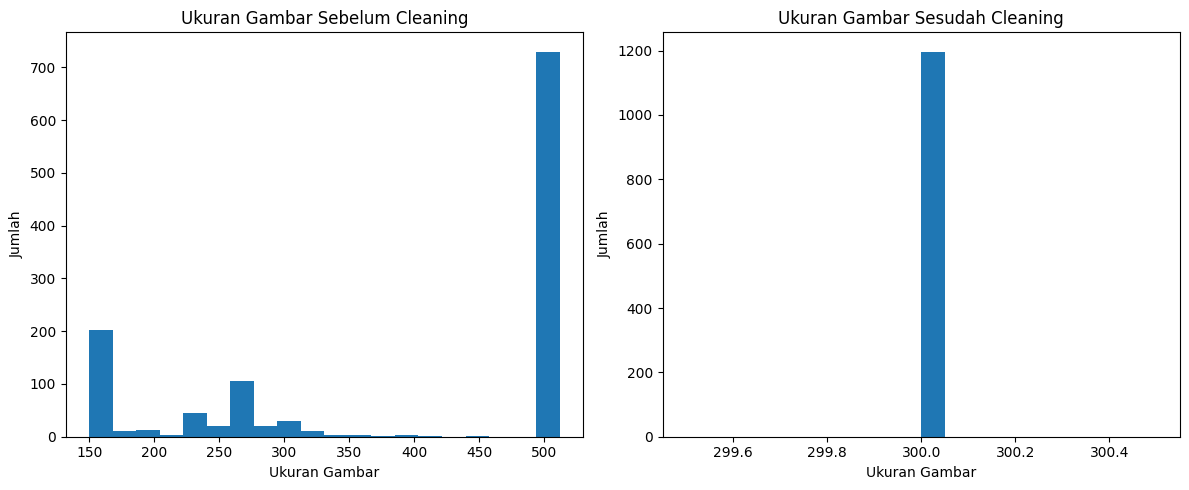

In [70]:
raw_sizes = []
clean_sizes = []

# RAW DATASET
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            raw_sizes.append(img.size[0])
        except:
            pass

# CLEAN DATASET
for root, dirs, files in os.walk(clean_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            clean_sizes.append(img.size[0])
        except:
            pass

# VISUALISASI
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Sebelum Cleaning
ax[0].hist(raw_sizes, bins=20)
ax[0].set_title("Ukuran Gambar Sebelum Cleaning")
ax[0].set_xlabel("Ukuran Gambar")
ax[0].set_ylabel("Jumlah")

# Sesudah Cleaning
ax[1].hist(clean_sizes, bins=20)
ax[1].set_title("Ukuran Gambar Sesudah Cleaning")
ax[1].set_xlabel("Ukuran Gambar")
ax[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()

### **Insight:**

Visualisasi menunjukkan bahwa dataset sebelum proses cleaning memiliki variasi ukuran gambar yang cukup beragam. Sebagian besar gambar memiliki ukuran besar sekitar 500 piksel, namun masih terdapat beberapa gambar dengan ukuran yang lebih kecil dan tidak konsisten.

Setelah proses cleaning dilakukan, distribusi ukuran gambar menjadi lebih konsisten dengan dominasi ukuran gambar yang seragam. Hal ini menunjukkan bahwa proses cleaning berhasil meningkatkan kualitas dataset dan mempermudah proses preprocessing pada tahap training model. Konsistensi ukuran gambar membantu model menerima input yang lebih stabil sehingga proses pembelajaran dapat berjalan lebih optimal.

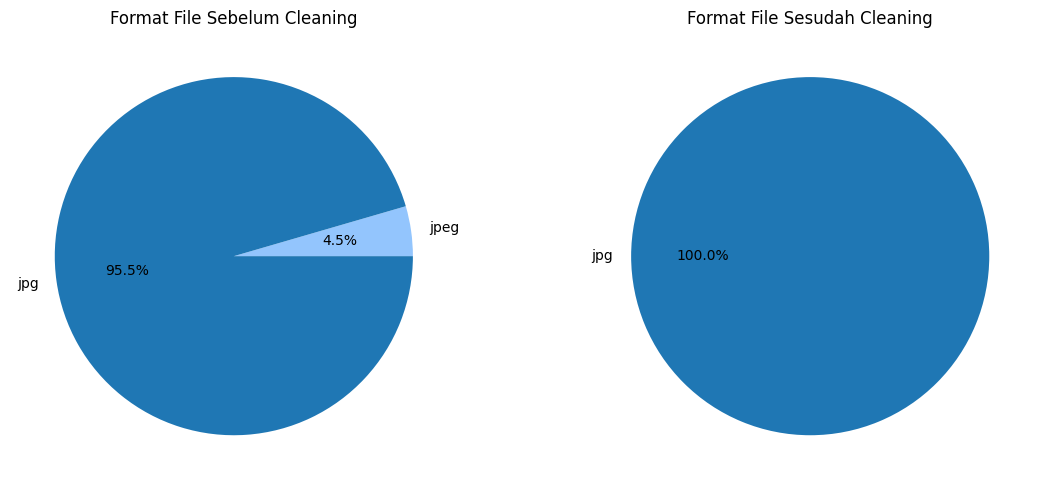

In [71]:
raw_formats = {}
clean_formats = {}

# RAW DATASET
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        ext = file.split('.')[-1].lower()
        raw_formats[ext] = raw_formats.get(ext, 0) + 1

# CLEAN DATASET
for root, dirs, files in os.walk(clean_path):
    for file in files:
        ext = file.split('.')[-1].lower()
        clean_formats[ext] = clean_formats.get(ext, 0) + 1

# Warna
colors_raw = ['#93C5FD', '#1f77b4']   # biru tua, biru muda
colors_clean = ['#1f77b4', '#93C5FD']

# VISUALISASI
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Sebelum Cleaning
ax[0].pie(
    raw_formats.values(),
    labels=raw_formats.keys(),
    autopct='%1.1f%%',
    colors=colors_raw
)

ax[0].set_title("Format File Sebelum Cleaning")

# Sesudah Cleaning
ax[1].pie(
    clean_formats.values(),
    labels=clean_formats.keys(),
    autopct='%1.1f%%',
    colors=colors_clean
)

ax[1].set_title("Format File Sesudah Cleaning")

plt.tight_layout()
plt.show()

### **Insight:**

Sebelum proses cleaning, dataset masih terdiri dari beberapa format file yaitu JPG dan JPEG. Format JPG mendominasi dataset dengan persentase sekitar 95.5%, sedangkan format JPEG hanya sebagian kecil dari keseluruhan dataset dengan persentase 4.5%. Setelah cleaning dilakukan, seluruh gambar berhasil diseragamkan ke dalam format JPG sehingga dataset menjadi lebih konsisten. Standardisasi format file membantu mengurangi potensi error pada proses loading data dan membuat pipeline preprocessing menjadi lebih stabil dan efisien.

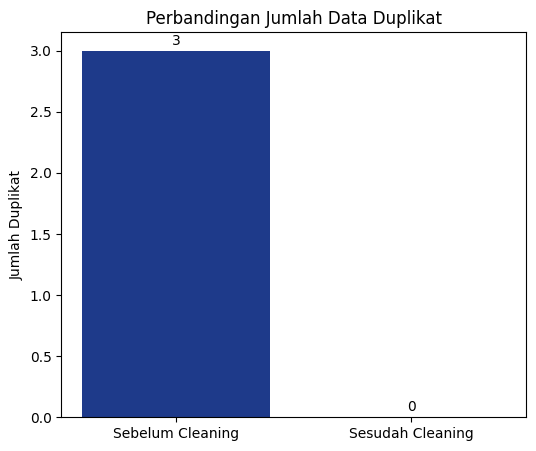

In [72]:
# Fungsi menghitung jumlah duplikat
def count_duplicates(dataset_path):
    hashes = {}
    duplicates = 0

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            path = os.path.join(root, file)

            try:
                with open(path, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                if file_hash in hashes:
                    duplicates += 1
                else:
                    hashes[file_hash] = path

            except:
                pass

    return duplicates

# Hitung duplikat
raw_duplicates = count_duplicates(dataset_path)
clean_duplicates = count_duplicates(clean_path)

# Visualisasi
plt.figure(figsize=(6,5))

bars = plt.bar(
    ["Sebelum Cleaning", "Sesudah Cleaning"],
    [raw_duplicates, clean_duplicates],
    color=['#1E3A8A', '#93C5FD']
)

plt.title("Perbandingan Jumlah Data Duplikat")
plt.ylabel("Jumlah Duplikat")

# Menampilkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        str(height),
        ha='center'
    )

plt.show()

### **Insight:**

Sebelum proses cleaning, dataset masih memiliki 3 data duplikat. Setelah cleaning dilakukan, seluruh data duplikat berhasil dihapus sehingga jumlah data duplikat menjadi 0. Penghapusan data duplikat sangat penting untuk mengurangi risiko overfitting pada model deep learning. Data yang berulang dapat menyebabkan model terlalu menghafal pola tertentu dan menurunkan kemampuan generalisasi terhadap data baru.

### Pertanyaan 2: Bagaimana distribusi warna dan tingkat pencahayaan pada setiap kategori sampah memengaruhi kebutuhan preprocessing gambar dalam pengembangan model EcoSort AI?

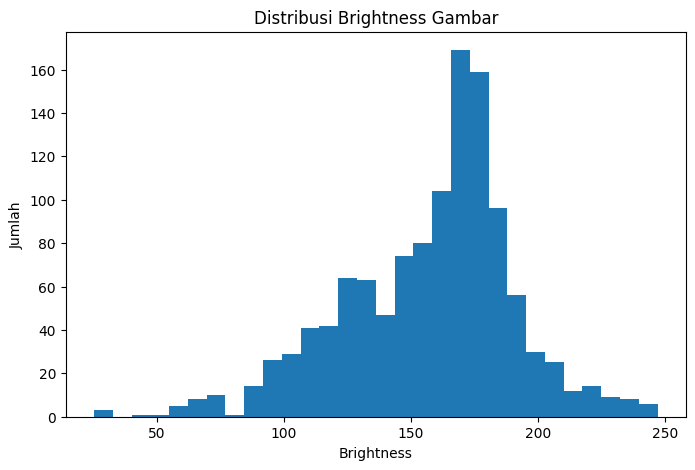

In [73]:
brightness = []

for root, dirs, files in os.walk(clean_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path).convert('L')
            brightness.append(np.mean(img))
        except:
            pass

plt.figure(figsize=(8,5))

plt.hist(brightness, bins=30)

plt.title("Distribusi Brightness Gambar")
plt.xlabel("Brightness")
plt.ylabel("Jumlah")

plt.show()

### **Insight:**

Distribusi brightness menunjukkan bahwa dataset memiliki tingkat pencahayaan yang cukup beragam dengan mayoritas gambar berada pada tingkat brightness menengah hingga tinggi. Rata-rata distribusi brightness berkisar di angka 150 hingga 200, Variasi pencahayaan ini menunjukkan bahwa gambar diambil pada kondisi lingkungan yang berbeda-beda sehingga dataset menjadi lebih representatif terhadap kondisi nyata. Namun, variasi brightness yang terlalu ekstrem tetap perlu ditangani melalui preprocessing seperti normalisasi dan augmentasi brightness agar model lebih robust terhadap perubahan pencahayaan.

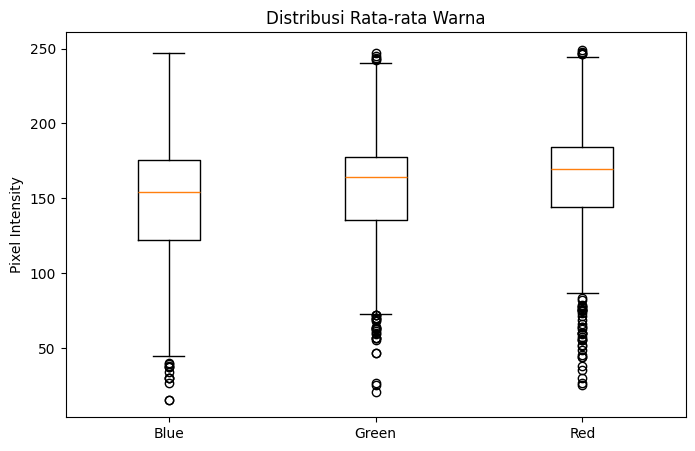

In [74]:
mean_colors = []

for root, dirs, files in os.walk(clean_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = cv2.imread(path)

            mean_color = img.mean(axis=(0,1))
            mean_colors.append(mean_color)
        except:
            pass

mean_colors = np.array(mean_colors)

plt.figure(figsize=(8,5))

plt.boxplot([
    mean_colors[:,0],
    mean_colors[:,1],
    mean_colors[:,2]
])

plt.xticks([1,2,3], ['Blue', 'Green', 'Red'])

plt.title("Distribusi Rata-rata Warna")

plt.ylabel("Pixel Intensity")

plt.show()

### **Insight:**

Visualisasi distribusi rata-rata warna menunjukkan bahwa kanal warna Red, Green, dan Blue memiliki sebaran intensitas yang cukup beragam. Kanal warna merah dan hijau cenderung memiliki intensitas yang lebih tinggi dibandingkan biru.

Hal ini menunjukkan bahwa dataset memiliki variasi karakteristik visual antar kategori sampah, seperti warna alami pada sampah organik serta warna reflektif pada kategori kaca dan logam. Variasi warna ini dapat membantu model mempelajari pola visual yang lebih kompleks.

### Pertanyaan 3: Bagaimana kemampuan fitur hasil ekstraksi gambar dalam membedakan kategori sampah berdasarkan persebaran fitur PCA pada tahap pengembangan model EcoSort AI?

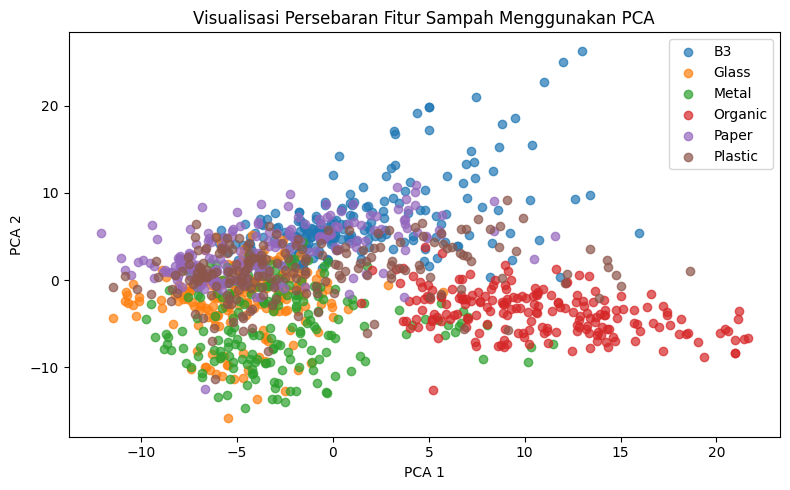

In [75]:
# Ambil fitur
X = df_final.drop(columns=["Nama File", "Kategori"])

# PCA menjadi 2 dimensi
pca = PCA(n_components=2)
hasil_pca = pca.fit_transform(X)

# DataFrame PCA
df_pca = pd.DataFrame({
    "PCA1": hasil_pca[:,0],
    "PCA2": hasil_pca[:,1],
    "Kategori": df_final["Kategori"]
})

# Mapping label
label_map = {
    0: "B3",
    1: "Glass",
    2: "Metal",
    3: "Organic",
    4: "Paper",
    5: "Plastic"
}

df_pca["Kategori"] = df_pca["Kategori"].map(label_map)

# Plot
plt.figure(figsize=(8,5))

for kategori in df_pca["Kategori"].unique():
    subset = df_pca[df_pca["Kategori"] == kategori]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=kategori,
        alpha=0.7
    )

plt.title("Visualisasi Persebaran Fitur Sampah Menggunakan PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.legend()
plt.tight_layout()
plt.show()

### **Insight:**

Berdasarkan visualisasi PCA, terlihat bahwa beberapa kategori sampah membentuk pola persebaran yang cukup terpisah, seperti kategori Organic yang cenderung berada di sisi kiri bawah dan Metal yang lebih terkonsentrasi di bagian kanan bawah, sehingga menunjukkan bahwa fitur hasil ekstraksi gambar mampu menangkap karakteristik visual tertentu dari masing-masing kategori. Namun, beberapa kategori seperti Glass, Plastic, dan Paper masih memiliki banyak titik yang saling bertumpuk, yang mengindikasikan adanya kemiripan karakteristik visual antar kategori tersebut sehingga berpotensi menyebabkan model klasifikasi mengalami kesulitan dalam membedakannya secara akurat.

# **Kesimpulan**

#### Berdasarkan hasil explanatory analysis, proses cleaning berhasil meningkatkan kualitas dataset EcoSort AI melalui konsistensi ukuran gambar, standardisasi format file, serta penghapusan data duplikat. Dataset juga menunjukkan variasi brightness dan distribusi warna yang cukup beragam, sehingga mampu merepresentasikan kondisi visual yang lebih realistis.

#### Selain itu, visualisasi PCA menunjukkan bahwa beberapa kategori memiliki karakteristik visual yang cukup terpisah, meskipun masih terdapat beberapa kelas yang memiliki kemiripan visual. Secara keseluruhan, dataset dinilai cukup baik untuk pengembangan model klasifikasi sampah.